In [ ]:
# ------------------------------------------------------------
# Imports
# - Core Python utils, plotting
# - sklearn for stratified splitting
# - PyTorch for model + training
# Download dataset with kagglehub + locate the pickle file
# - Downloads (or reuses cached) RadioML2016 dataset
# - Finds the .pkl file that stores (mod, snr) -> samples
# - Prints the local path so you know where the data lives
# ------------------------------------------------------------

import os, glob, pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import kagglehub

# Download dataset files (cached after first run)
path = kagglehub.dataset_download("nolasthitnotomorrow/radioml2016-deepsigcom")
print("Dataset path:", path)

# Find the pickle file
pkl_files = glob.glob(os.path.join(path, "**", "*.pkl"), recursive=True) + \
            glob.glob(os.path.join(path, "**", "*.pickle"), recursive=True)

if not pkl_files:
    raise FileNotFoundError(f"No .pkl/.pickle found under {path}. Check files: {os.listdir(path)}")

pkl_path = pkl_files[0]
print("Data file:", pkl_path)

100%|██████████| 279M/279M [00:02<00:00, 133MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/nolasthitnotomorrow/radioml2016-deepsigcom/versions/1
Data file: /root/.cache/kagglehub/datasets/nolasthitnotomorrow/radioml2016-deepsigcom/versions/1/RML2016.10a_dict.pkl


In [ ]:
# ------------------------------------------------------------
# Load the dataset dictionary and print core stats
# - Loads Xd: dict with keys (modulation, SNR)
# - Extracts sorted list of modulations and SNR levels
# - Prints: number of modulations, number of SNR levels, total samples
# ------------------------------------------------------------

with open(pkl_path, "rb") as f:
    Xd = pickle.load(f, encoding="latin1")  # dict: (mod, snr) -> array (N,2,128)

mods = sorted({k[0] for k in Xd.keys()})
snrs = sorted({k[1] for k in Xd.keys()})

n_samples = sum(arr.shape[0] for arr in Xd.values())
example_shape = next(iter(Xd.values())).shape[1:]

print("Num modulations:", len(mods), mods)
print("Num SNR levels:", len(snrs), snrs)
print("Num (mod,SNR) bins:", len(Xd))
print("Total samples:", n_samples)
print("One example shape (channels, length):", example_shape)

Num modulations: 11 ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
Num SNR levels: 20 [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Num (mod,SNR) bins: 220
Total samples: 220000
One example shape (channels, length): (2, 128)


In [ ]:
# ------------------------------------------------------------
# Print SNR distribution
# - Aggregates counts across all modulations for each SNR value
# - Uses fmt_k() to display large counts as k/M for readability
# ------------------------------------------------------------

def fmt_k(n: int) -> str:
    if n >= 1_000_000:
        s = f"{n/1_000_000:.1f}M"
    elif n >= 1_000:
        s = f"{n/1_000:.1f}k"
    else:
        s = str(n)
    return s.rstrip("0").rstrip(".")

counts_by_snr = defaultdict(int)
for (mod, snr), arr in Xd.items():
    counts_by_snr[snr] += arr.shape[0]

for snr in sorted(counts_by_snr):
    print(f"{snr} dB -> {fmt_k(counts_by_snr[snr])}")

-20 dB -> 11.0k
-18 dB -> 11.0k
-16 dB -> 11.0k
-14 dB -> 11.0k
-12 dB -> 11.0k
-10 dB -> 11.0k
-8 dB -> 11.0k
-6 dB -> 11.0k
-4 dB -> 11.0k
-2 dB -> 11.0k
0 dB -> 11.0k
2 dB -> 11.0k
4 dB -> 11.0k
6 dB -> 11.0k
8 dB -> 11.0k
10 dB -> 11.0k
12 dB -> 11.0k
14 dB -> 11.0k
16 dB -> 11.0k
18 dB -> 11.0k


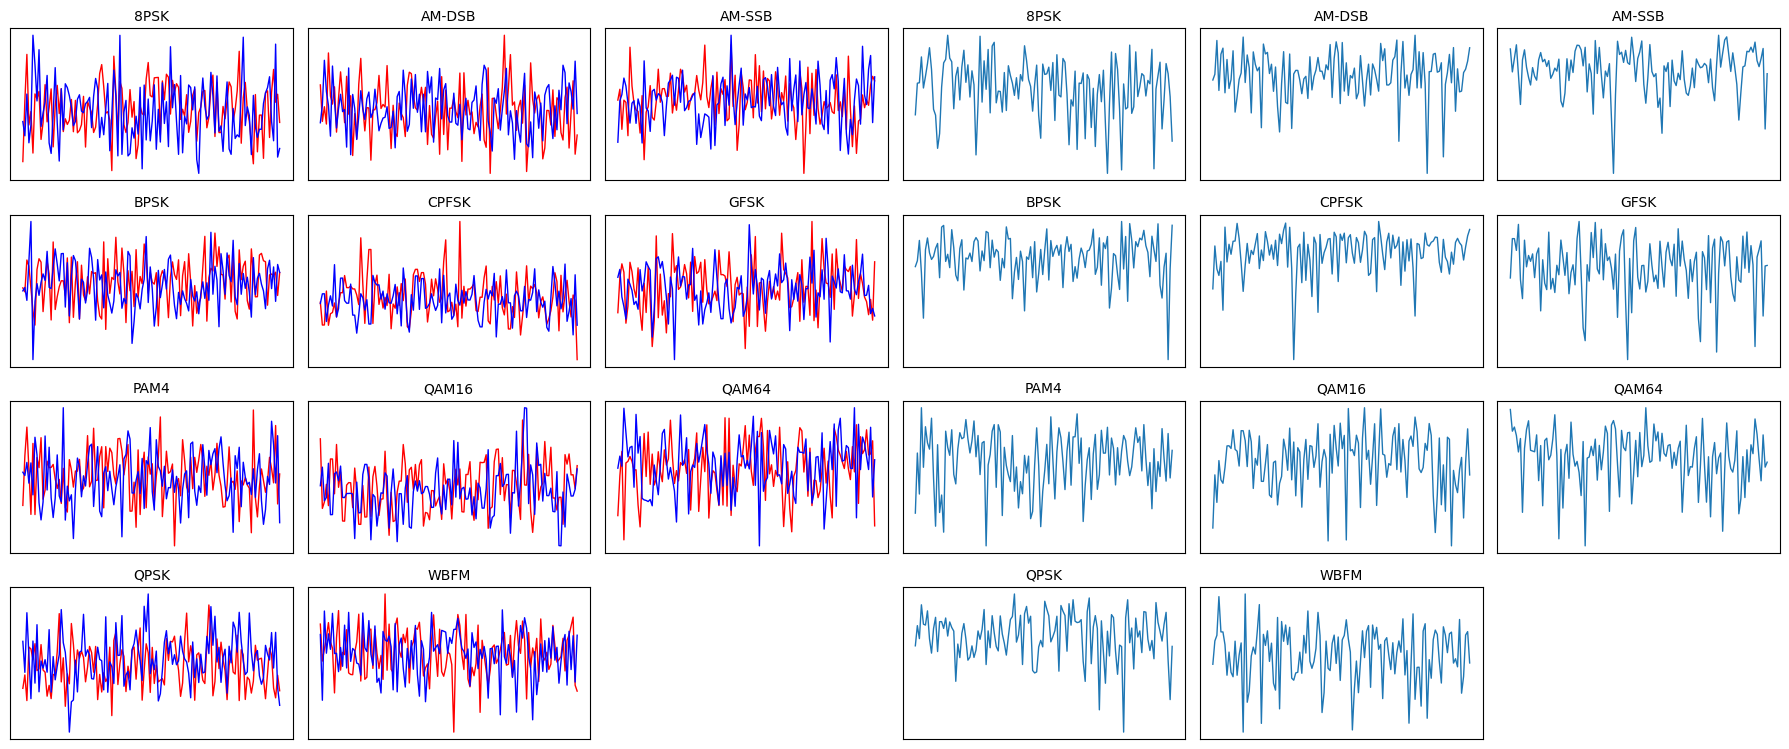

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


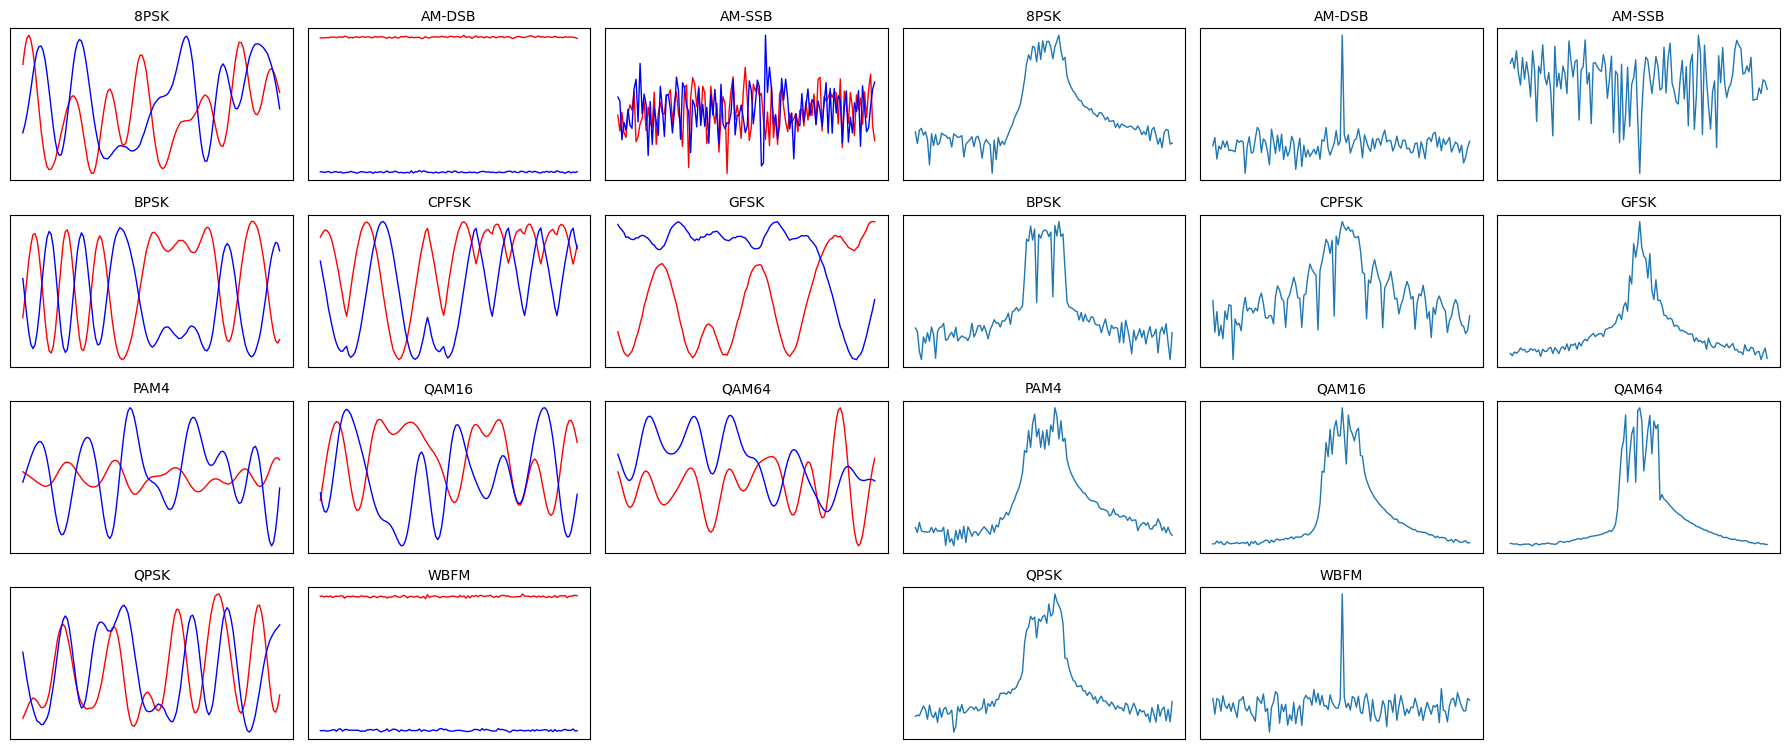

In [ ]:
import numpy as np

# ------------------------------------------------------------
# Helper functions for visualization
# - power_spectrum_db(): computes FFT magnitude (in dB) of complex signal (I + jQ)
# - plot_mods_time_and_spectrum_for_snr():
#     * Builds a grid of plots for ALL modulations at a fixed SNR
#     * Left half: time-domain I/Q curves
#     * Right half: power spectrum curves
#     * Randomly picks one example per modulation at that SNR
# Visualize low-SNR and high-SNR examples
# - Picks lowest SNR in dataset (e.g., -20 dB) and highest (e.g., 18 dB)
# - Produces two figures:
#     * One for low SNR (noisier / harder to distinguish)
#     * One for high SNR (cleaner / easier to distinguish)
# - Layout: time plots + spectrum plots per modulation
# ------------------------------------------------------------

def power_spectrum_db(iq_2xN: np.ndarray):
    """
    iq_2xN: shape (2, N) where [0]=I, [1]=Q
    Returns frequency axis (normalized) and magnitude in dB.
    """
    I = iq_2xN[0]
    Q = iq_2xN[1]
    x = I + 1j * Q

    X = np.fft.fftshift(np.fft.fft(x))
    mag = np.abs(X) + 1e-12
    mag_db = 20.0 * np.log10(mag / mag.max())

    N = x.size
    f = np.fft.fftshift(np.fft.fftfreq(N, d=1.0))  # normalized frequency
    return f, mag_db

def plot_mods_time_and_spectrum_for_snr(Xd, mods, snr_value, seed=0):
    """
    Creates a figure with time plots (left half) and power spectra (right half),
    for all modulations at a fixed SNR.
    Layout: 4 rows x 6 cols -> time in cols 0-2, spectrum in cols 3-5 .
    """
    rng = np.random.default_rng(seed)

    n_mod = len(mods)
    rows, cols = 4, 6
    fig, axes = plt.subplots(rows, cols, figsize=(18, 8))
    # fig.suptitle(f"Time Domain (left) and Power Spectrum (right) at SNR = {snr_value} dB", fontsize=16)

    for i, mod in enumerate(mods):
        r = i // 3
        c_time = i % 3
        c_spec = c_time + 3

        # pick a random example from this (mod, snr)
        arr = Xd[(mod, snr_value)]   # shape (N,2,128)
        idx = rng.integers(0, arr.shape[0])
        ex = arr[idx]                # shape (2,128)

        # Time plot
        ax_t = axes[r, c_time]
        ax_t.plot(ex[0], "r-", linewidth=1)  # I
        ax_t.plot(ex[1], "b-", linewidth=1)  # Q
        ax_t.set_title(f"{mod}", fontsize=10)
        ax_t.set_xticks([])
        ax_t.set_yticks([])

        # Spectrum plot
        ax_s = axes[r, c_spec]
        f, mag_db = power_spectrum_db(ex)
        ax_s.plot(f, mag_db, linewidth=1)
        ax_s.set_title(f"{mod}", fontsize=10)
        ax_s.set_xticks([])
        ax_s.set_yticks([])

    # Turn off unused subplot(s) if any (since 11 mods but 12 slots)
    for j in range(n_mod, rows * 3):
        r = j // 3
        c_time = j % 3
        c_spec = c_time + 3
        axes[r, c_time].axis("off")
        axes[r, c_spec].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

low_snr = min(snrs)
high_snr = max(snrs)

plot_mods_time_and_spectrum_for_snr(Xd, mods, low_snr, seed=0)

print("-" * 180)

print("-" * 180)

plot_mods_time_and_spectrum_for_snr(Xd, mods, high_snr, seed=0)

In [ ]:
# ------------------------------------------------------------
# Convert dict format -> flat arrays and perform stratified splitting
# - Flattens Xd[(mod,snr)] arrays into:
#     X: (N, 2, 128)
#     y: (N,) integer labels for modulation class
#     snr: (N,) SNR value per example
# - Creates a stratification label combining (mod, snr)
#   so that train/val/test are UNIFORMLY distributed in both modulation and SNR
# - Split ratios:
#     60% train
#     20% validation
#     20% test
# - Prints shapes + optional SNR counts per split for verification
# ------------------------------------------------------------

mod_to_int = {m: i for i, m in enumerate(mods)}
int_to_mod = {i: m for m, i in mod_to_int.items()}

X_list, y_list, snr_list = [], [], []
for (mod, snr), arr in Xd.items():
    X_list.append(arr)  # (N,2,128)
    y_list.append(np.full(arr.shape[0], mod_to_int[mod], dtype=np.int64))
    snr_list.append(np.full(arr.shape[0], snr, dtype=np.int64))

X = np.vstack(X_list).astype(np.float32)  # (220000,2,128)
y = np.concatenate(y_list)
snr = np.concatenate(snr_list)

# Stratify by (mod, snr) -> keeps uniform distribution in both
snr_min = snr.min()
strat = y * 100 + (snr - snr_min)

# 60% train, 40% temp
X_train, X_tmp, y_train, y_tmp, snr_train, snr_tmp = train_test_split(
    X, y, snr, test_size=0.40, random_state=0, stratify=strat
)

# temp -> 20% val, 20% test (split temp in half)
strat_tmp = y_tmp * 100 + (snr_tmp - snr_min)
X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_tmp, y_tmp, snr_tmp, test_size=0.50, random_state=0, stratify=strat_tmp
)

mu = X_train.mean(axis=(0, 2), keepdims=True)          # shape (1,2,1)
sd = X_train.std(axis=(0, 2), keepdims=True) + 1e-6    # shape (1,2,1)

# Keep everything float32
mu = mu.astype(np.float32)
sd = sd.astype(np.float32)

X_train = (X_train - mu) / sd
X_val   = (X_val   - mu) / sd
X_test  = (X_test  - mu) / sd

print("Split shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape,   y_val.shape)
print("Test :", X_test.shape,  y_test.shape)

# Quick SNR distribution check in each split
def count_snr(arr_snr):
    d = defaultdict(int)
    for s in arr_snr:
        d[int(s)] += 1
    return d

print("\nSNR counts (train):", {k: fmt_k(v) for k,v in sorted(count_snr(snr_train).items())})
print("SNR counts (val)  :", {k: fmt_k(v) for k,v in sorted(count_snr(snr_val).items())})
print("SNR counts (test) :", {k: fmt_k(v) for k,v in sorted(count_snr(snr_test).items())})

Split shapes:
Train: (132000, 2, 128) (132000,)
Val  : (44000, 2, 128) (44000,)
Test : (44000, 2, 128) (44000,)

SNR counts (train): {-20: '6.6k', -18: '6.6k', -16: '6.6k', -14: '6.6k', -12: '6.6k', -10: '6.6k', -8: '6.6k', -6: '6.6k', -4: '6.6k', -2: '6.6k', 0: '6.6k', 2: '6.6k', 4: '6.6k', 6: '6.6k', 8: '6.6k', 10: '6.6k', 12: '6.6k', 14: '6.6k', 16: '6.6k', 18: '6.6k'}
SNR counts (val)  : {-20: '2.2k', -18: '2.2k', -16: '2.2k', -14: '2.2k', -12: '2.2k', -10: '2.2k', -8: '2.2k', -6: '2.2k', -4: '2.2k', -2: '2.2k', 0: '2.2k', 2: '2.2k', 4: '2.2k', 6: '2.2k', 8: '2.2k', 10: '2.2k', 12: '2.2k', 14: '2.2k', 16: '2.2k', 18: '2.2k'}
SNR counts (test) : {-20: '2.2k', -18: '2.2k', -16: '2.2k', -14: '2.2k', -12: '2.2k', -10: '2.2k', -8: '2.2k', -6: '2.2k', -4: '2.2k', -2: '2.2k', 0: '2.2k', 2: '2.2k', 4: '2.2k', 6: '2.2k', 8: '2.2k', 10: '2.2k', 12: '2.2k', 14: '2.2k', 16: '2.2k', 18: '2.2k'}


In [ ]:
# ------------------------------------------------------------
# Create PyTorch DataLoaders
# - Moves data into TensorDataset objects
# - train_loader shuffles for SGD training
# - val_loader/test_loader do NOT shuffle (evaluation consistency)
# - Batch sizes chosen for speed; adjust if you run out of memory
# - Sets device = CUDA if available, else CPU
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def make_loader(X_np, y_np, batch_size=512, shuffle=True):
    X_t = torch.from_numpy(X_np)              # (N,2,128)
    y_t = torch.from_numpy(y_np).long()       # (N,)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

train_loader = make_loader(X_train, y_train, batch_size=512, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   batch_size=1024, shuffle=False)
test_loader  = make_loader(X_test,  y_test,  batch_size=1024, shuffle=False)

Using device: cuda


In [ ]:
# ------------------------------------------------------------
# Define CNN model (matches proposal architecture)
# Architecture:
#   (Conv1D -> BatchNorm -> ReLU -> MaxPool) x 2
#   Conv1D -> BatchNorm -> ReLU
#   Global Average Pooling over time
#   Dense -> ReLU -> Dropout
#   Dense -> logits (Softmax handled by CrossEntropyLoss)
#
# Input format expected by Conv1D:
#   (batch, channels=2, length=128)
# ------------------------------------------------------------

class AMC_CNN(nn.Module):
    """
    Architecture (as in your proposal):
      (Conv1D -> BN -> ReLU -> Pool) x 2
      Conv1D -> BN -> ReLU -> GlobalAvgPool
      Dense(ReLU+Dropout) -> Dense -> Softmax
    """
    def __init__(self, num_classes=11):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.GELU(),

            nn.AdaptiveAvgPool1d(1)  # Global average pooling over time
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),            # (B,256,1) -> (B,256)
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = AMC_CNN(num_classes=len(mods)).to(device)
print(cnn_model)

AMC_CNN(
  (features): Sequential(
    (0): Conv1d(2, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): GELU(approximate='none')
   

In [ ]:
# ------------------------------------------------------------
# ResNet-1D model for I/Q (2x128)
# - Basic residual blocks (Conv-BN-ReLU-Conv-BN + skip)
# - Strided conv is used for downsampling (instead of maxpool)
# ------------------------------------------------------------

class BasicBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, k=3):
        super().__init__()
        p = k // 2

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=k, stride=stride, padding=p, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.gelu  = nn.GELU()

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=k, stride=1, padding=p, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)

        self.downsample = None
        if stride != 1 or in_ch != out_ch:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.gelu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = self.gelu(out)
        return out


class ResNet1D_Small(nn.Module):
    """
    ResNet-1D (small):
      stem: Conv7 -> BN -> ReLU
      layer1: 2 blocks @ 64
      layer2: 2 blocks @ 128 (first block stride=2)
      layer3: 2 blocks @ 256 (first block stride=2)
      head: GAP -> MLP -> logits
    """
    def __init__(self, num_classes=11, dropout=0.3):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=7, stride=1, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.GELU(),
        )

        self.layer1 = nn.Sequential(
            BasicBlock1D(64, 64, stride=1, k=3),
            BasicBlock1D(64, 64, stride=1, k=3),
        )

        self.layer2 = nn.Sequential(
            BasicBlock1D(64, 128, stride=2, k=3),
            BasicBlock1D(128, 128, stride=1, k=3),
        )

        self.layer3 = nn.Sequential(
            BasicBlock1D(128, 256, stride=2, k=3),
            BasicBlock1D(256, 256, stride=1, k=3),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.head = nn.Sequential(
            nn.Flatten(),            # (B,256,1) -> (B,256)
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = self.head(x)
        return x


resnet_model = ResNet1D_Small(num_classes=len(mods)).to(device)
print(resnet_model)


ResNet1D_Small(
  (stem): Sequential(
    (0): Conv1d(2, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
  )
  (layer1): Sequential(
    (0): BasicBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (gelu): GELU(approximate='none')
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (gelu): GELU(approximate='none')
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), 

In [ ]:
# ------------------------------------------------------------
# Training loop (records train/val loss and accuracy each epoch)
# Now trains TWO models:
#   1) cnn_model  -> saves best_amc_cnn.pt
#   2) resnet_model -> saves best_resnet1d.pt
# and stores separate loss histories for plotting.
# ------------------------------------------------------------

def run_epoch(model, loader, criterion, optimizer=None):
    """
    If optimizer is None -> evaluation mode.
    Returns: avg_loss, avg_accuracy
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == yb).sum().item()
        total += xb.size(0)

    return total_loss / total, total_correct / total


EPOCHS = 30
cnn_criterion = nn.CrossEntropyLoss()
res_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# ============================================================
# 1) Train CNN
# ============================================================
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_cnn = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cnn, mode="max", patience=3, factor=0.5
)

cnn_train_losses, cnn_val_losses = [], []
cnn_train_accs, cnn_val_accs = [], []

best_val_acc_cnn = -1.0
ckpt_path_cnn = "best_amc_cnn.pt"

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(cnn_model, train_loader, cnn_criterion, optimizer=optimizer_cnn)
    va_loss, va_acc = run_epoch(cnn_model, val_loader, cnn_criterion, optimizer=None)

    scheduler_cnn.step(va_acc)

    # checkpoint best CNN
    if va_acc > best_val_acc_cnn:
        best_val_acc_cnn = va_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": cnn_model.state_dict(),
            "optimizer_state_dict": optimizer_cnn.state_dict(),
            "val_acc": va_acc,
            "val_loss": va_loss,
        }, ckpt_path_cnn)

    cnn_train_losses.append(tr_loss); cnn_val_losses.append(va_loss)
    cnn_train_accs.append(tr_acc);   cnn_val_accs.append(va_acc)

    current_lr = optimizer_cnn.param_groups[0]["lr"]
    print(f"[CNN] Epoch {epoch:02d} | train loss {tr_loss:.4f}, acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f}, acc {va_acc:.4f} | lr {current_lr:.2e}")

# load best CNN
best_ckpt = torch.load(ckpt_path_cnn, map_location=device)
cnn_model.load_state_dict(best_ckpt["model_state_dict"])
print(f"[CNN] Loaded BEST checkpoint from epoch {best_ckpt['epoch']} "
      f"(val acc={best_ckpt['val_acc']:.4f}, val loss={best_ckpt['val_loss']:.4f})")

print("-" * 120)

print("-" * 120)



# ============================================================
# 2) Train ResNet
# ============================================================
resnet_model = ResNet1D_Small(num_classes=len(mods)).to(device)

optimizer_res = torch.optim.Adam(resnet_model.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler_res = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_res, mode="min", patience=2, factor=0.5
)

res_train_losses, res_val_losses = [], []
res_train_accs, res_val_accs = [], []

best_val_loss_res = float("inf")
best_val_acc_res = -1.0
ckpt_path_res = "best_resnet1d.pt"

early_stop_patience = 5
epochs_no_improve = 0
min_delta = 1e-4

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(resnet_model, train_loader, res_criterion, optimizer=optimizer_res)
    va_loss, va_acc = run_epoch(resnet_model, val_loader, res_criterion, optimizer=None)

    scheduler_res.step(va_loss)

    # checkpoint + early stopping based on validation loss
    if va_loss < best_val_loss_res - min_delta:
        best_val_loss_res = va_loss
        best_val_acc_res = va_acc
        epochs_no_improve = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": resnet_model.state_dict(),
            "optimizer_state_dict": optimizer_res.state_dict(),
            "val_acc": va_acc,
            "val_loss": va_loss,
        }, ckpt_path_res)
    else:
        epochs_no_improve += 1

    res_train_losses.append(tr_loss)
    res_val_losses.append(va_loss)
    res_train_accs.append(tr_acc)
    res_val_accs.append(va_acc)

    current_lr = optimizer_res.param_groups[0]["lr"]
    print(f"[ResNet] Epoch {epoch:02d} | train loss {tr_loss:.4f}, acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f}, acc {va_acc:.4f} | lr {current_lr:.2e}")

    if epochs_no_improve >= early_stop_patience:
        print(f"[ResNet] Early stopping triggered at epoch {epoch:02d}")
        break

# load best ResNet
best_ckpt = torch.load(ckpt_path_res, map_location=device)
resnet_model.load_state_dict(best_ckpt["model_state_dict"])
print(f"[ResNet] Loaded BEST checkpoint from epoch {best_ckpt['epoch']} "
      f"(val acc={best_ckpt['val_acc']:.4f}, val loss={best_ckpt['val_loss']:.4f})")


print("\nCheckpoint files:")
print(" - CNN   :", ckpt_path_cnn)
print(" - ResNet:", ckpt_path_res)



[CNN] Epoch 01 | train loss 1.6221, acc 0.4027 | val loss 1.3073, acc 0.5029 | lr 3.00e-04
[CNN] Epoch 02 | train loss 1.2849, acc 0.5032 | val loss 1.2577, acc 0.5184 | lr 3.00e-04
[CNN] Epoch 03 | train loss 1.2460, acc 0.5182 | val loss 1.2402, acc 0.5250 | lr 3.00e-04
[CNN] Epoch 04 | train loss 1.2227, acc 0.5285 | val loss 1.2098, acc 0.5369 | lr 3.00e-04
[CNN] Epoch 05 | train loss 1.2055, acc 0.5363 | val loss 1.1890, acc 0.5454 | lr 3.00e-04
[CNN] Epoch 06 | train loss 1.1891, acc 0.5441 | val loss 1.1780, acc 0.5448 | lr 3.00e-04
[CNN] Epoch 07 | train loss 1.1752, acc 0.5504 | val loss 1.1680, acc 0.5515 | lr 3.00e-04
[CNN] Epoch 08 | train loss 1.1640, acc 0.5536 | val loss 1.1644, acc 0.5498 | lr 3.00e-04
[CNN] Epoch 09 | train loss 1.1541, acc 0.5573 | val loss 1.1575, acc 0.5564 | lr 3.00e-04
[CNN] Epoch 10 | train loss 1.1466, acc 0.5613 | val loss 1.1531, acc 0.5519 | lr 3.00e-04
[CNN] Epoch 11 | train loss 1.1403, acc 0.5635 | val loss 1.1489, acc 0.5613 | lr 3.00e-04

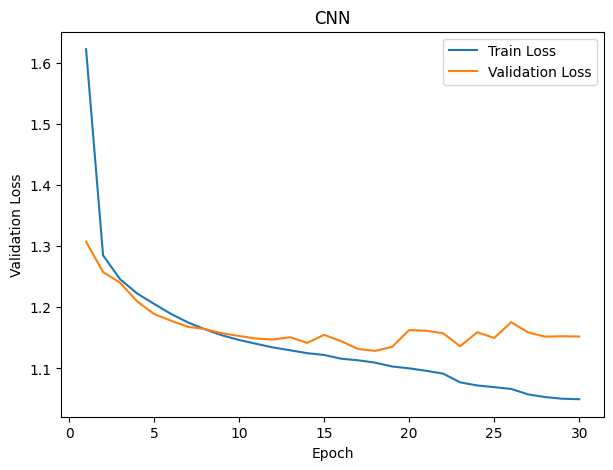

-------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------


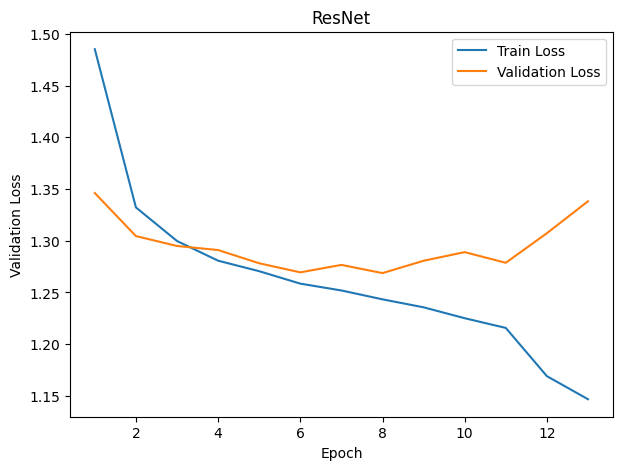

In [ ]:
# ------------------------------------------------------------
# Plot training/validation loss vs epoch
# ------------------------------------------------------------

# CNN loss figure
plt.figure(figsize=(7,5))
plt.plot(range(1, EPOCHS+1), cnn_train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS+1), cnn_val_losses,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("CNN")
plt.legend()
plt.show()

print("-" * 85)

print("-" * 85)

# ResNet loss figure
plt.figure(figsize=(7,5))
plt.plot(range(1, len(res_train_losses)+1), res_train_losses, label="Train Loss")
plt.plot(range(1, len(res_val_losses)+1), res_val_losses,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("ResNet")
plt.legend()
plt.show()


CNN   Test loss: 1.1302 | Test accuracy: 0.5680
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
ResNet Test loss: 1.2699 | Test accuracy: 0.6044

Accuracy vs SNR (test set):
-20 dB -> CNN 0.0909 | ResNet 0.0968
-18 dB -> CNN 0.0959 | ResNet 0.0977
-16 dB -> CNN 0.1018 | ResNet 0.1032
-14 dB -> CNN 0.1118 | ResNet 0.1186
-12 dB -> CNN 0.1573 | ResNet 0.1577
-10 dB -> CNN 0.2491 | ResNet 0.2191
 -8 dB -> CNN 0.3673 | ResNet 0.3327
 -6 dB -> CNN 0.5164 | ResNet 0.5168
 -4 dB -> CNN 0.6505 | ResNet 0.6823
 -2 dB -> CNN 0.7300 | ResNet 0.7791
  0 dB -> CNN 0.8000 | ResNet 0.8664
  2 dB -> CNN 0.8177 | ResNet 0.8886
  4 dB -> CNN 0.8291 | ResNet 0.8950
  6 dB -> CNN 0.8314 | ResNet 0.9014
  8 dB -> CNN 0.8295 | ResNet 0.9014
 10 dB -> CNN 0.8373 | ResNet 0.9041
 12 dB -> CNN 0.8332 | ResNet 0.9091
 14 dB -> CNN 0.8405 | ResNet 0.9105
 16 dB

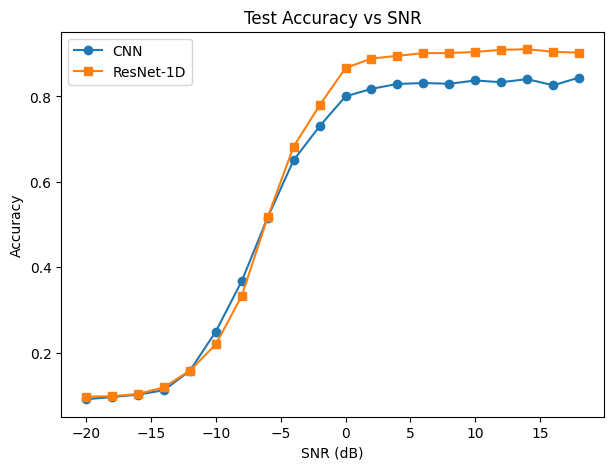

In [ ]:
# ------------------------------------------------------------
# Evaluate BOTH models on test set + plot Accuracy vs SNR together
# ------------------------------------------------------------

def accuracy_vs_snr(model, X_test, y_test, snr_test, batch=2048):
    model.eval()
    snr_levels = sorted(set(snr_test.tolist()))
    correct_by_snr = defaultdict(int)
    total_by_snr = defaultdict(int)

    with torch.no_grad():
        X_t = torch.from_numpy(X_test).to(device)
        y_t = torch.from_numpy(y_test).to(device)

        for i in range(0, X_t.size(0), batch):
            xb = X_t[i:i+batch]
            yb = y_t[i:i+batch]
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            true  = yb.cpu().numpy()

            snr_batch = snr_test[i:i+batch]
            for p, t, s in zip(preds, true, snr_batch):
                s = int(s)
                total_by_snr[s] += 1
                if p == t:
                    correct_by_snr[s] += 1

    acc_curve = [correct_by_snr[s] / total_by_snr[s] for s in snr_levels]
    return snr_levels, acc_curve


# Overall test accuracy (CNN)
cnn_test_loss, cnn_test_acc = run_epoch(cnn_model, test_loader, cnn_criterion, optimizer=None)
print(f"CNN   Test loss: {cnn_test_loss:.4f} | Test accuracy: {cnn_test_acc:.4f}")

print("-" * 100)

print("-" * 100)

# Overall test accuracy (ResNet)
res_test_loss, res_test_acc = run_epoch(resnet_model, test_loader, res_criterion, optimizer=None)
print(f"ResNet Test loss: {res_test_loss:.4f} | Test accuracy: {res_test_acc:.4f}")

# Accuracy vs SNR curves
snr_levels, cnn_curve = accuracy_vs_snr(cnn_model, X_test, y_test, snr_test)
_,          res_curve = accuracy_vs_snr(resnet_model, X_test, y_test, snr_test)

print("\nAccuracy vs SNR (test set):")
for s, a, b in zip(snr_levels, cnn_curve, res_curve):
    print(f"{s:>3} dB -> CNN {a:.4f} | ResNet {b:.4f}")

print("-" * 85)

print("-" * 85)

# Plot BOTH curves on the same figure
plt.figure(figsize=(7,5))
plt.plot(snr_levels, cnn_curve, marker="o", label="CNN")
plt.plot(snr_levels, res_curve, marker="s", label="ResNet-1D")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Test Accuracy vs SNR")
plt.legend()
plt.show()

High-SNR pool: (110000, 2, 128) (110000,)
Low-SNR  pool: (110000, 2, 128) (110000,)
High SNR levels: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Low  SNR levels: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2]

High->Low split shapes:
Train (high SNR): (110000, 2, 128) (110000,)
Val   (low  SNR): (55000, 2, 128) (55000,)
Test  (low  SNR): (55000, 2, 128) (55000,)
[CNN] Epoch 01 | train loss 1.0620, acc 0.5816 | val loss 3.5465, acc 0.1677 | lr 3.00e-04
[CNN] Epoch 02 | train loss 0.4919, acc 0.7459 | val loss 4.0802, acc 0.1672 | lr 3.00e-04
[CNN] Epoch 03 | train loss 0.4329, acc 0.7793 | val loss 4.5339, acc 0.1608 | lr 3.00e-04
[CNN] Epoch 04 | train loss 0.3920, acc 0.7980 | val loss 4.5774, acc 0.1712 | lr 3.00e-04
[CNN] Epoch 05 | train loss 0.3636, acc 0.8106 | val loss 4.2518, acc 0.1727 | lr 3.00e-04
[CNN] Epoch 06 | train loss 0.3377, acc 0.8235 | val loss 4.4548, acc 0.1740 | lr 3.00e-04
[CNN] Epoch 07 | train loss 0.3241, acc 0.8284 | val loss 4.5187, acc 0.1792 | lr 3.00e-04
[CNN] 

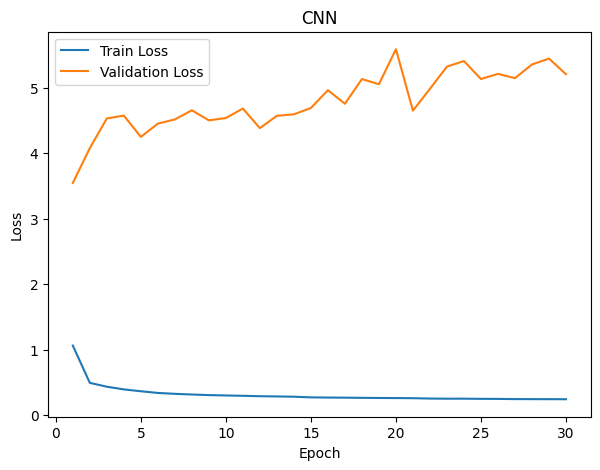

------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------


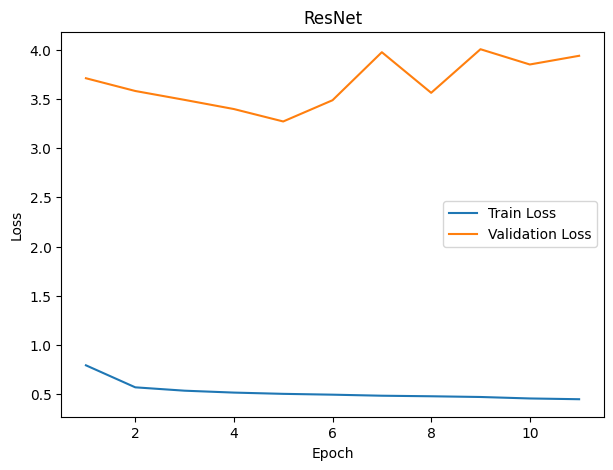


[CNN] Test loss: 4.9909 | Test accuracy: 0.1845
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
[ResNet] Test loss: 3.4867 | Test accuracy: 0.1917

Accuracy vs SNR on LOW-SNR test set:
-20 dB -> CNN 0.0909 | ResNet 0.0909
-18 dB -> CNN 0.0909 | ResNet 0.0909
-16 dB -> CNN 0.0909 | ResNet 0.0909
-14 dB -> CNN 0.0909 | ResNet 0.0909
-12 dB -> CNN 0.0909 | ResNet 0.0909
-10 dB -> CNN 0.0909 | ResNet 0.0909
 -8 dB -> CNN 0.0945 | ResNet 0.0947
 -6 dB -> CNN 0.1313 | ResNet 0.1433
 -4 dB -> CNN 0.3744 | ResNet 0.3845
 -2 dB -> CNN 0.6996 | ResNet 0.7491
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------


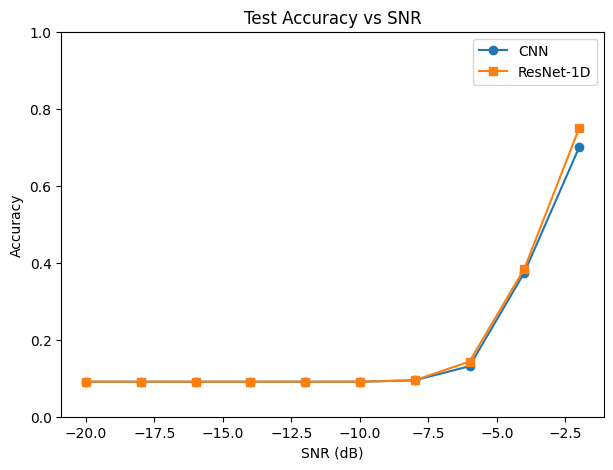

In [ ]:
# ============================================================
# SECOND EXPERIMENT:
# Train on HIGH SNR only,
# validate on LOW SNR,
# test on a SEPARATE LOW SNR split
#
# Change HIGH_SNR_MIN if you want a stricter definition of "high"
# Example:
#   HIGH_SNR_MIN = 0   -> train on {0, 2, 4, ..., 18}, val/test on {-20,...,-2}
#   HIGH_SNR_MIN = 2   -> train on {2, 4, ..., 18},    val/test on {-20,...,0}
# ============================================================

HIGH_SNR_MIN = 0

# ------------------------------------------------------------
# 1) Build the high/low SNR split from the ORIGINAL raw arrays
#    (X, y, snr) from Cell 4
# ------------------------------------------------------------
high_mask = snr >= HIGH_SNR_MIN
low_mask  = snr <  HIGH_SNR_MIN

X_high = X[high_mask].astype(np.float32)
y_high = y[high_mask]
snr_high = snr[high_mask]

X_low = X[low_mask].astype(np.float32)
y_low = y[low_mask]
snr_low = snr[low_mask]

print("High-SNR pool:", X_high.shape, y_high.shape)
print("Low-SNR  pool:", X_low.shape, y_low.shape)
print("High SNR levels:", sorted(np.unique(snr_high).tolist()))
print("Low  SNR levels:", sorted(np.unique(snr_low).tolist()))

# Use ALL high-SNR data for training
X_train_hilo = X_high.copy()
y_train_hilo = y_high.copy()
snr_train_hilo = snr_high.copy()

# Split LOW-SNR pool into validation + final test
# Stratify by (mod, snr) so both low-SNR val/test remain balanced
snr_low_min = snr_low.min()
strat_low = y_low * 100 + (snr_low - snr_low_min)

X_val_hilo, X_test_hilo, y_val_hilo, y_test_hilo, snr_val_hilo, snr_test_hilo = train_test_split(
    X_low, y_low, snr_low,
    test_size=0.50,
    random_state=0,
    stratify=strat_low
)

# Normalize using HIGH-SNR TRAIN statistics only
mu_hilo = X_train_hilo.mean(axis=(0, 2), keepdims=True).astype(np.float32)
sd_hilo = (X_train_hilo.std(axis=(0, 2), keepdims=True) + 1e-6).astype(np.float32)

X_train_hilo = (X_train_hilo - mu_hilo) / sd_hilo
X_val_hilo   = (X_val_hilo   - mu_hilo) / sd_hilo
X_test_hilo  = (X_test_hilo  - mu_hilo) / sd_hilo

print("\nHigh->Low split shapes:")
print("Train (high SNR):", X_train_hilo.shape, y_train_hilo.shape)
print("Val   (low  SNR):", X_val_hilo.shape,   y_val_hilo.shape)
print("Test  (low  SNR):", X_test_hilo.shape,  y_test_hilo.shape)

# New loaders for this second experiment
train_loader_hilo = make_loader(X_train_hilo, y_train_hilo, batch_size=512,  shuffle=True)
val_loader_hilo   = make_loader(X_val_hilo,   y_val_hilo,   batch_size=1024, shuffle=False)
test_loader_hilo  = make_loader(X_test_hilo,  y_test_hilo,  batch_size=1024, shuffle=False)


# ------------------------------------------------------------
# 2) Generic trainer so we can retrain BOTH models on this split
# ------------------------------------------------------------
def train_model_for_split(
    model,
    tag,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    ckpt_path,
    epochs=30,
    monitor="acc",              # "acc" or "loss"
    early_stop_patience=None,
    min_delta=1e-4
):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    if monitor == "acc":
        best_metric = -1.0
    elif monitor == "loss":
        best_metric = float("inf")
    else:
        raise ValueError("monitor must be 'acc' or 'loss'")

    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion, optimizer=None)

        # scheduler follows the SAME quantity used for selection
        if scheduler is not None:
            if monitor == "acc":
                scheduler.step(va_acc)
            else:
                scheduler.step(va_loss)

        # decide whether this epoch improved
        if monitor == "acc":
            improved = va_acc > best_metric + min_delta
            metric_value = va_acc
        else:
            improved = va_loss < best_metric - min_delta
            metric_value = va_loss

        if improved:
            best_metric = metric_value
            epochs_no_improve = 0
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": va_acc,
                "val_loss": va_loss,
            }, ckpt_path)
        else:
            epochs_no_improve += 1

        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        train_accs.append(tr_acc)
        val_accs.append(va_acc)

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"[{tag}] Epoch {epoch:02d} | "
              f"train loss {tr_loss:.4f}, acc {tr_acc:.4f} | "
              f"val loss {va_loss:.4f}, acc {va_acc:.4f} | "
              f"lr {current_lr:.2e}")

        if early_stop_patience is not None and epochs_no_improve >= early_stop_patience:
            print(f"[{tag}] Early stopping triggered at epoch {epoch:02d}")
            break

    best_ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(best_ckpt["model_state_dict"])
    print(f"[{tag}] Loaded BEST checkpoint from epoch {best_ckpt['epoch']} "
          f"(val acc={best_ckpt['val_acc']:.4f}, val loss={best_ckpt['val_loss']:.4f})")

    return model, train_losses, val_losses, train_accs, val_accs


# ------------------------------------------------------------
# 3) Train CNN on the HIGH->LOW split
# ------------------------------------------------------------
cnn_model_hilo = AMC_CNN(num_classes=len(mods)).to(device)

optimizer_cnn_hilo = torch.optim.Adam(
    cnn_model_hilo.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)
scheduler_cnn_hilo = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cnn_hilo, mode="max", patience=3, factor=0.5
)

ckpt_path_cnn_hilo = "best_amc_cnn_high_to_low.pt"

cnn_model_hilo, cnn_train_losses_hilo, cnn_val_losses_hilo, cnn_train_accs_hilo, cnn_val_accs_hilo = train_model_for_split(
    model=cnn_model_hilo,
    tag="CNN",
    train_loader=train_loader_hilo,
    val_loader=val_loader_hilo,
    criterion=cnn_criterion,
    optimizer=optimizer_cnn_hilo,
    scheduler=scheduler_cnn_hilo,
    ckpt_path=ckpt_path_cnn_hilo,
    epochs=EPOCHS,
    monitor="acc",
    early_stop_patience=None
)


# ------------------------------------------------------------
# 4) Train ResNet on the HIGH->LOW split
# ------------------------------------------------------------
resnet_model_hilo = ResNet1D_Small(num_classes=len(mods)).to(device)

optimizer_res_hilo = torch.optim.Adam(
    resnet_model_hilo.parameters(),
    lr=3e-4,
    weight_decay=1e-3
)
scheduler_res_hilo = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_res_hilo, mode="max", patience=2, factor=0.5
)

ckpt_path_res_hilo = "best_resnet1d_high_to_low.pt"

resnet_model_hilo, res_train_losses_hilo, res_val_losses_hilo, res_train_accs_hilo, res_val_accs_hilo = train_model_for_split(
    model=resnet_model_hilo,
    tag="ResNet",
    train_loader=train_loader_hilo,
    val_loader=val_loader_hilo,
    criterion=res_criterion,
    optimizer=optimizer_res_hilo,
    scheduler=scheduler_res_hilo,
    ckpt_path=ckpt_path_res_hilo,
    epochs=EPOCHS,
    monitor="acc",
    early_stop_patience=5
)


# ------------------------------------------------------------
# 5) loss curves for the second experiment
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(range(1, len(cnn_train_losses_hilo)+1), cnn_train_losses_hilo, label="Train Loss")
plt.plot(range(1, len(cnn_val_losses_hilo)+1),   cnn_val_losses_hilo,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN")
plt.legend()
plt.show()

print("-" * 120)
print("-" * 120)

plt.figure(figsize=(7,5))
plt.plot(range(1, len(res_train_losses_hilo)+1), res_train_losses_hilo, label="Train Loss")
plt.plot(range(1, len(res_val_losses_hilo)+1),   res_val_losses_hilo,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet")
plt.legend()
plt.show()


# ------------------------------------------------------------
# 6) Evaluate on LOW-SNR test set
# ------------------------------------------------------------
cnn_test_loss_hilo, cnn_test_acc_hilo = run_epoch(
    cnn_model_hilo, test_loader_hilo, cnn_criterion, optimizer=None
)
print(f"\n[CNN] Test loss: {cnn_test_loss_hilo:.4f} | Test accuracy: {cnn_test_acc_hilo:.4f}")

res_test_loss_hilo, res_test_acc_hilo = run_epoch(
    resnet_model_hilo, test_loader_hilo, res_criterion, optimizer=None
)
print("-" * 100)
print("-" * 100)
print(f"[ResNet] Test loss: {res_test_loss_hilo:.4f} | Test accuracy: {res_test_acc_hilo:.4f}")

snr_levels_hilo, cnn_curve_hilo = accuracy_vs_snr(
    cnn_model_hilo, X_test_hilo, y_test_hilo, snr_test_hilo
)
_, res_curve_hilo = accuracy_vs_snr(
    resnet_model_hilo, X_test_hilo, y_test_hilo, snr_test_hilo
)

print("\nAccuracy vs SNR on LOW-SNR test set:")
for s, a, b in zip(snr_levels_hilo, cnn_curve_hilo, res_curve_hilo):
    print(f"{s:>3} dB -> CNN {a:.4f} | ResNet {b:.4f}")

print("-" * 100)
print("-" * 100)

# SECOND figure at the bottom
plt.figure(figsize=(7,5))
plt.plot(snr_levels_hilo, cnn_curve_hilo, marker="o", label="CNN")
plt.plot(snr_levels_hilo, res_curve_hilo, marker="s", label="ResNet-1D")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Test Accuracy vs SNR")
plt.ylim(0, 1)
plt.legend()
plt.show()